  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.1 MB/s eta 0:00:00
Đang tải bộ dữ liệu CNN/DailyMail...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,2.256984,1.986940
2,1.921371,1.945678
3,1.671716,1.949346
4,1.510857,1.965301



Đang đánh giá facebook/bart-base trên 100 mẫu test...



KẾT QUẢ facebook/bart-base:
ROUGE-1 : 0.3984
ROUGE-2 : 0.1729
ROUGE-L : 0.2691
BLEU    : 0.1438


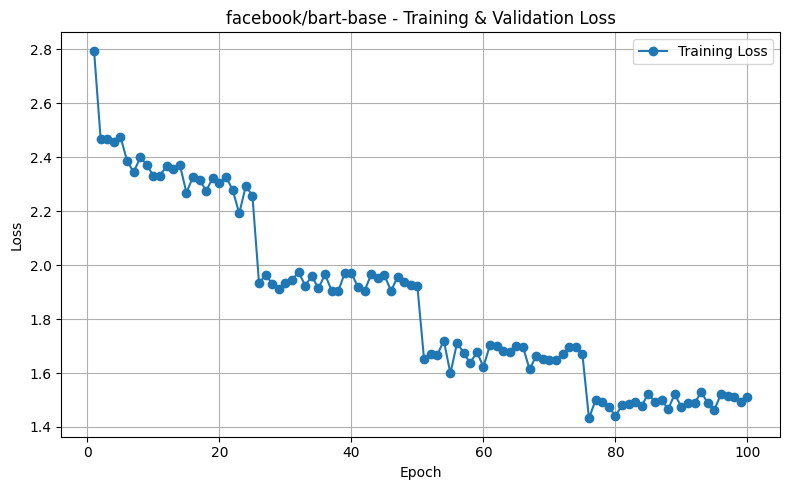

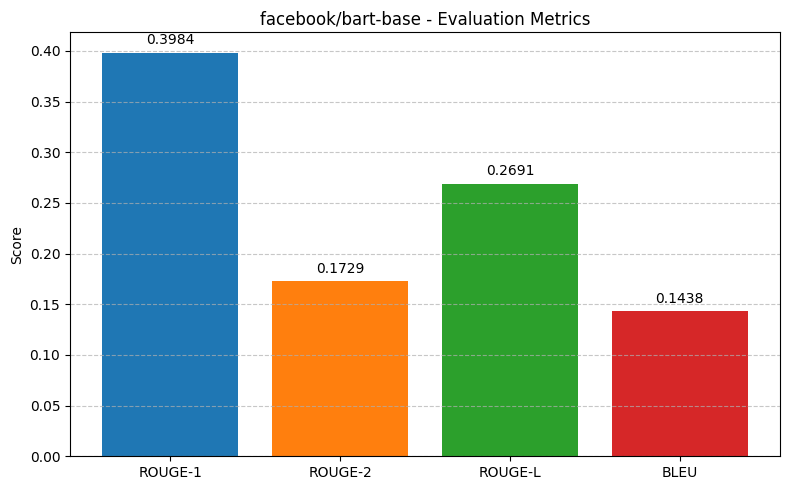


HOÀN THÀNH!


In [1]:
# -*- coding: utf-8 -*-
"""Huấn luyện và đánh giá BART-base cho tóm tắt CNN/DailyMail"""

# Cài thư viện (chạy một lần)
!pip install transformers datasets evaluate rouge_score sacrebleu matplotlib -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    BartTokenizer, BartForConditionalGeneration,
    Trainer, TrainingArguments, DataCollatorForSeq2Seq
)
import evaluate

# ------------------------- 1. Load dataset -------------------------
print("Đang tải bộ dữ liệu CNN/DailyMail...")
dataset = load_dataset("cnn_dailymail", "3.0.0")

train_data = dataset["train"].shuffle(seed=42).select(range(10000))
test_data = dataset["test"].shuffle(seed=42).select(range(500))

print(f"Số mẫu huấn luyện: {len(train_data)}")
print(f"Số mẫu kiểm tra: {len(test_data)}")

# ------------------------- 2. Tiền xử lý -------------------------
def preprocess_function(examples, tokenizer, prefix=""):
    inputs = [prefix + doc for doc in examples["article"]]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True)
    labels = tokenizer(examples["highlights"], max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# ------------------------- 3. Huấn luyện & đánh giá -------------------------
model_name = "facebook/bart-base"
prefix = ""

print(f"\n{'='*60}")
print(f"BẮT ĐẦU HUẤN LUYỆN: {model_name}")
print(f"{'='*60}")

tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

tokenized_train = train_data.map(
    lambda x: preprocess_function(x, tokenizer, prefix), batched=True
)
tokenized_test = test_data.map(
    lambda x: preprocess_function(x, tokenizer, prefix), batched=True
)

training_args = TrainingArguments(
    output_dir="./results_bart",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=4,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    fp16=True,
    report_to="none"
)

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
)

trainer.train()

# Lấy lịch sử loss
history = trainer.state.log_history
epochs = []
train_losses = []
val_losses = []
for log in history:
    if 'loss' in log and 'epoch' in log:
        epochs.append(log['epoch'])
        train_losses.append(log['loss'])
    if 'eval_loss' in log and 'epoch' in log:
        val_losses.append(log['eval_loss'])

# Đánh giá trên 100 mẫu
print(f"\nĐang đánh giá {model_name} trên 100 mẫu test...")
predictions, references = [], []
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

for i in range(100):
    input_text = test_data[i]["article"]
    ref_text = test_data[i]["highlights"]
    inputs = tokenizer(prefix + input_text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=128, num_beams=4, early_stopping=True)
    pred_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    predictions.append(pred_text)
    references.append([ref_text])

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
rouge_result = rouge.compute(predictions=predictions, references=[r[0] for r in references])
bleu_result = bleu.compute(predictions=predictions, references=references)

print(f"\nKẾT QUẢ {model_name}:")
print(f"ROUGE-1 : {rouge_result['rouge1']:.4f}")
print(f"ROUGE-2 : {rouge_result['rouge2']:.4f}")
print(f"ROUGE-L : {rouge_result['rougeL']:.4f}")
print(f"BLEU    : {bleu_result['bleu']:.4f}")

# ------------------------- 4. Vẽ đồ thị -------------------------
# 4.1. Đồ thị loss
if train_losses and val_losses:
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
    if len(val_losses) == len(train_losses):
        plt.plot(range(1, len(val_losses)+1), val_losses, marker='s', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Training & Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 4.2. Biểu đồ các chỉ số
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
scores = [rouge_result['rouge1'], rouge_result['rouge2'], rouge_result['rougeL'], bleu_result['bleu']]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{score:.4f}',
             ha='center', va='bottom')
plt.ylabel('Score')
plt.title(f'{model_name} - Evaluation Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nHOÀN THÀNH!")